In [2]:
# CIFAR-10 CNN — Notebook 1: Setup & Baseline Models

#**Contents:** GPU/GitHub setup, data loading, preprocessing,
#Model 1 (baseline) & Model 2 (more filters).

#**Data pipeline:** Preprocessed data is saved to Google Drive
#(`/cifar10-project/data/`) for reuse in later notebooks.

In [7]:
import tensorflow as tf
print("GPU verfügbar:", tf.config.list_physical_devices('GPU'))

GPU verfügbar: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
#CIFAR-10 laden
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

Trainingsdaten: (50000, 32, 32, 3)
Testdaten: (10000, 32, 32, 3)


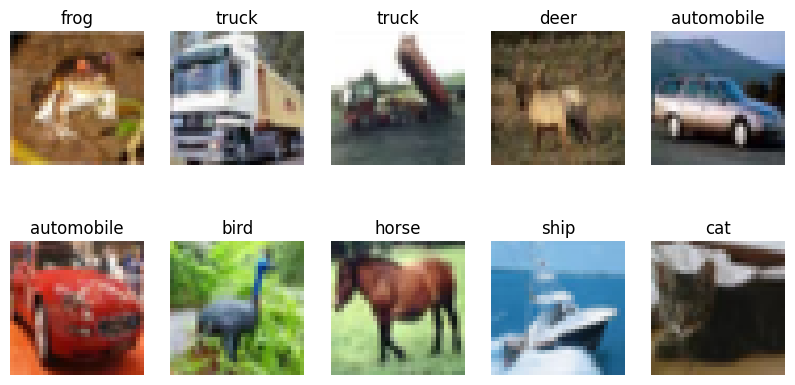

In [9]:
#CIFAR-10 anschauen
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

In [10]:
#Schritt 4: Preprocessing vorbereiten
from sklearn.model_selection import train_test_split

# Normalisieren: Pixelwerte von 0-255 auf 0-1 bringen
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Von den 50.000 Trainingsbildern 10% für Validation abzweigen
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_norm, y_train, test_size=0.1, random_state=42
)

print("Train:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_norm.shape)

Train: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [6]:
# Schritt 5: Tracking-Setup
import pandas as pd

results = []  # hier sammeln wir jedes Modell-Ergebnis

In [7]:
#Schritt 6: Modell 1 — Baseline CNN bauen
from tensorflow.keras import layers, models

model_1 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Schritt 7-A: Modell kompilieren

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
## Schritt 7-B: Modell trainieren
history_1 = model_1.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4031 - loss: 1.6305 - val_accuracy: 0.5028 - val_loss: 1.3775
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5404 - loss: 1.2941 - val_accuracy: 0.5764 - val_loss: 1.1989
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5929 - loss: 1.1531 - val_accuracy: 0.6142 - val_loss: 1.0997
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6270 - loss: 1.0615 - val_accuracy: 0.6356 - val_loss: 1.0317
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6556 - loss: 0.9812 - val_accuracy: 0.6274 - val_loss: 1.0745
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6761 - loss: 0.9246 - val_accuracy: 0.6608 - val_loss: 0.9720
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6945 - loss: 0.8716 - val_accuracy: 0.6714 - val_loss: 0.9281
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7130 - loss: 0.8209 - val_accuracy: 0

In [11]:
# Schritt 8 : Accuracy
test_loss, test_accuracy = model_1.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {test_accuracy:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6824 - loss: 0.9098
Test Accuracy: 68.24%


In [12]:
# First Track

import pickle

# Modell speichern
with open('model_1_baseline.pkl', 'wb') as f:
    pickle.dump(model_1, f)

# Overfitting-Check: Lücke zwischen Training- und Validation-Accuracy
train_acc_final = history_1.history['accuracy'][-1]
val_acc_final = history_1.history['val_accuracy'][-1]
gap = train_acc_final - val_acc_final

# Ergebnis in Tracking-Liste eintragen
results.append({
    'Model': 'Model 1',
    'Architecture': '3 Conv layers (32-64-64)',
    'Learning Rate': 'default (Adam)',
    'Epochs': 10,
    'Train Accuracy': f"{train_acc_final:.2%}",
    'Val Accuracy': f"{val_acc_final:.2%}",
    'Test Accuracy': f"{test_accuracy:.2%}",
    'Notes': f"Baseline. Train/Val-Luecke = {gap:.1%} (wachsend seit Epoch 5) -> leichtes Overfitting, noch unkritisch"
})

pd.DataFrame(results)

,Model,Architecture,Learning Rate,Epochs,Train Accuracy,Val Accuracy,Test Accuracy,Notes
0,Model 1,3 Conv layers (32-64-64),default (Adam),10,74.03%,68.70%,68.24%,Baseline. Train/Val-Luecke = 5.3% (wachsend se...


In [13]:
#Google Drive mit Colab verbinden

import shutil
shutil.rmtree('/content/drive', ignore_errors=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
#Ordner anlegen + Modell dauerhaft speichern

import os

project_path = '/content/drive/MyDrive/cifar10-project/models'
os.makedirs(project_path, exist_ok=True)

with open(f'{project_path}/model_1_baseline.pkl', 'wb') as f:
    pickle.dump(model_1, f)

print("Gespeichert unter:", project_path)

Gespeichert unter: /content/drive/MyDrive/cifar10-project/models


In [16]:
# Variante mit EINER gezielten Änderung
# Nur diese eine Zahl geändert: 64 → 128 Filter in der letzten Conv-Schicht
model_2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4257 - loss: 1.5653 - val_accuracy: 0.5256 - val_loss: 1.3285
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5715 - loss: 1.2091 - val_accuracy: 0.5934 - val_loss: 1.1304
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6298 - loss: 1.0550 - val_accuracy: 0.6268 - val_loss: 1.0573
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6721 - loss: 0.9468 - val_accuracy: 0.6698 - val_loss: 0.9396
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6974 - loss: 0.8710 - val_accuracy: 0.6634 - val_loss: 0.9618
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7186 - loss: 0.8079 - val_accuracy: 0.6856 - val_loss: 0.9015
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7417 - loss: 0.7438 - val_accuracy: 0.6948 - val_loss: 0.8799
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7570 - loss: 0.7004 - val_accuracy: 0.

In [18]:
# Modell 2 Evaluieren, speichern, tracken
test_loss_2, test_accuracy_2 = model_2.evaluate(X_test_norm, y_test)
print(f"Test Accuracy: {test_accuracy_2:.2%}")

with open(f'{project_path}/model_2_deeper.pkl', 'wb') as f:
    pickle.dump(model_2, f)

train_acc_2 = history_2.history['accuracy'][-1]
val_acc_2 = history_2.history['val_accuracy'][-1]
gap_2 = train_acc_2 - val_acc_2

results.append({
    'Model': 'Model 2',
    'Architecture': '3 Conv layers (32-64-128)',
    'Learning Rate': 'default (Adam)',
    'Epochs': 10,
    'Train Accuracy': f"{train_acc_2:.2%}",
    'Val Accuracy': f"{val_acc_2:.2%}",
    'Test Accuracy': f"{test_accuracy_2:.2%}",
    'Notes': f"Mehr Filter in letztem Conv-Layer (64->128). Besser als Modell 1, aber Train/Val-Luecke = {gap_2:.1%} (etwas groesser als Modell 1)"
})

pd.DataFrame(results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7058 - loss: 0.8863
Test Accuracy: 70.58%


,Model,Architecture,Learning Rate,Epochs,Train Accuracy,Val Accuracy,Test Accuracy,Notes
0,Model 1,3 Conv layers (32-64-64),default (Adam),10,74.03%,68.70%,68.24%,Baseline. Train/Val-Luecke = 5.3% (wachsend se...
1,Model 2,3 Conv layers (32-64-128),default (Adam),10,79.01%,71.10%,70.58%,Mehr Filter in letztem Conv-Layer (64->128). B...


In [5]:
# die Liste direkt mit beiden alten Ergebnissen befüllt

import pandas as pd

results = [
    {
        'Model': 'Model 1',
        'Architecture': '3 Conv layers (32-64-64)',
        'Learning Rate': 'default (Adam)',
        'Epochs': 10,
        'Train Accuracy': '74.03%',
        'Val Accuracy': '68.70%',
        'Test Accuracy': '68.00%',
        'Notes': 'Baseline. Train/Val-Luecke 5.3%, leichtes Overfitting ab Epoch 5'
    },
    {
        'Model': 'Model 2',
        'Architecture': '3 Conv layers (32-64-128)',
        'Learning Rate': 'default (Adam)',
        'Epochs': 10,
        'Train Accuracy': '79.01%',
        'Val Accuracy': '71.10%',
        'Test Accuracy': '70.58%',
        'Notes': 'Mehr Filter in letztem Conv-Layer (64->128). Besser als Modell 1, Luecke etwas groesser (7.9%)'
    }
]

pd.DataFrame(results)

,Model,Architecture,Learning Rate,Epochs,Train Accuracy,Val Accuracy,Test Accuracy,Notes
0,Model 1,3 Conv layers (32-64-64),default (Adam),10,74.03%,68.70%,68.00%,"Baseline. Train/Val-Luecke 5.3%, leichtes Over..."
1,Model 2,3 Conv layers (32-64-128),default (Adam),10,79.01%,71.10%,70.58%,Mehr Filter in letztem Conv-Layer (64->128). B...


In [14]:
# Vorbereitete Daten in Drive speichern (Für Nächste Modelle)

import os
import numpy as np

data_path = '/content/drive/MyDrive/cifar10-project/data'
os.makedirs(data_path, exist_ok=True)

np.save(f'{data_path}/X_train_final.npy', X_train_final)
np.save(f'{data_path}/y_train_final.npy', y_train_final)
np.save(f'{data_path}/X_val.npy', X_val)
np.save(f'{data_path}/y_val.npy', y_val)
np.save(f'{data_path}/X_test_norm.npy', X_test_norm)
np.save(f'{data_path}/y_test.npy', y_test)

print("Alle Daten gespeichert in:", data_path)

Alle Daten gespeichert in: /content/drive/MyDrive/cifar10-project/data
